# Comparing runs

The same figures as `bubble_analysis.ipynb` (bubble count, size, total area, ...) per train, with **several runs on one
plot**. Each run is a results folder exported by `bubble_inference.ipynb` (e.g. `results/r557`).

Every run shows a jump in the bubble count between two trains: the new population of bubbles made by the laser scan of
the area. The notebook finds that train in each run (the largest rise of the count from one train to the next, or set
`SCAN_TRAINS` by hand) and can **align the runs on it**: x = trains since the scan, 0 being the first train after it.
Runs start from very different bubble counts, so every metric is also shown **normalised by the run's maximum**
(each run's values divided by its largest value, so every run peaks at 1).

| section | figure |
|---|---|
| 2 | the scan train found in each run |
| 3 | bubble count (per frame and normalised) |
| 4 | bubble size: mean, median, Sauter r₃₂, largest |
| 5 | total bubble area and area covered |
| 6 | polydispersity, elongated bubbles, volume proxy |
| 7 | the jump at the scan, per run (table) |
| 8 | size distribution just before and just after the scan |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import bubble_stats as bst

bst.style()

## CONFIG

In [2]:
RESULTS = ["results/r557", "results/r560", "results/r569", "results/r574"]   # results folders to compare (max 8 runs)
REVIEWED_ONLY = False         # only frames ticked "Reviewed" in napari
IN_ANALYSIS_ONLY = True       # apply the exclusions chosen at export (inner_margin, drop_edge_bubbles, ...)
COMPUTE_COVERAGE = True       # area covered by bubbles (union of outlines; a few seconds per frame)
UM_PER_PX = 3.2

SCAN_TRAINS = {}              # train in which the laser-scan bubbles appear, e.g. {"r560": 3}; runs not given: found
MIN_JUMP = 1.3                # automatic search: the count must rise at least this much (x) from one train to the next
ALIGN_ON_SCAN = True          # x = trains since the scan (False: train number)

SAVE_FIGS = True
FIG_DIR = os.path.join("results", "compare")

def save(fig, name):
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=200, bbox_inches="tight")

## 1. Load

Metrics are recomputed from each folder's `bubbles.csv`, then averaged over the frames of a train (if there are several, the error bars show their standard error).

In [3]:
bubbles, m = bst.load_runs(RESULTS, reviewed_only=REVIEWED_ONLY, in_analysis_only=IN_ANALYSIS_ONLY,
                           compute_coverage=COMPUTE_COVERAGE, um_per_px=UM_PER_PX)
mt = bst.per_train(m)
COLORS = bst.run_colors(mt["run"].unique())     # one colour per run, the same in every figure
print(f"{mt['run'].nunique()} runs, {len(m)} frames, {len(bubbles)} bubbles")
display(mt.pivot(index="train", columns="run", values="n_bubbles"))

4 runs, 30 frames, 6197 bubbles


run,r557,r560,r569,r574
train,,,,
0,115.0,145.0,167.0,15.0
1,110.0,144.0,157.0,19.0
2,97.0,132.0,151.0,24.0
3,98.0,227.0,401.0,25.0
4,294.0,191.0,363.0,584.0
5,227.0,116.0,288.0,624.0
6,202.0,92.0,253.0,590.0
7,186.0,NaN,NaN,NaN
8,160.0,NaN,NaN,NaN


## 2. The laser scan in each run

`jump` = bubble count in the scan train / count in the train before. Check it, and set `SCAN_TRAINS` for any run where it is wrong.

In [4]:
scan = bst.find_scan_trains(mt, SCAN_TRAINS, min_jump=MIN_JUMP)
A = bst.align_runs(mt, scan, align=ALIGN_ON_SCAN)                    # absolute values
N = bst.align_runs(mt, scan, align=ALIGN_ON_SCAN, normalise=True)    # divided by each run's maximum

,run,scan_train,how,count_before,count_at_scan,jump
0,r557,4,found,98,294,3.00
1,r560,3,found,132,227,1.72
2,r569,3,found,151,401,2.66
3,r574,4,found,25,584,23.36


## 3. Bubble count

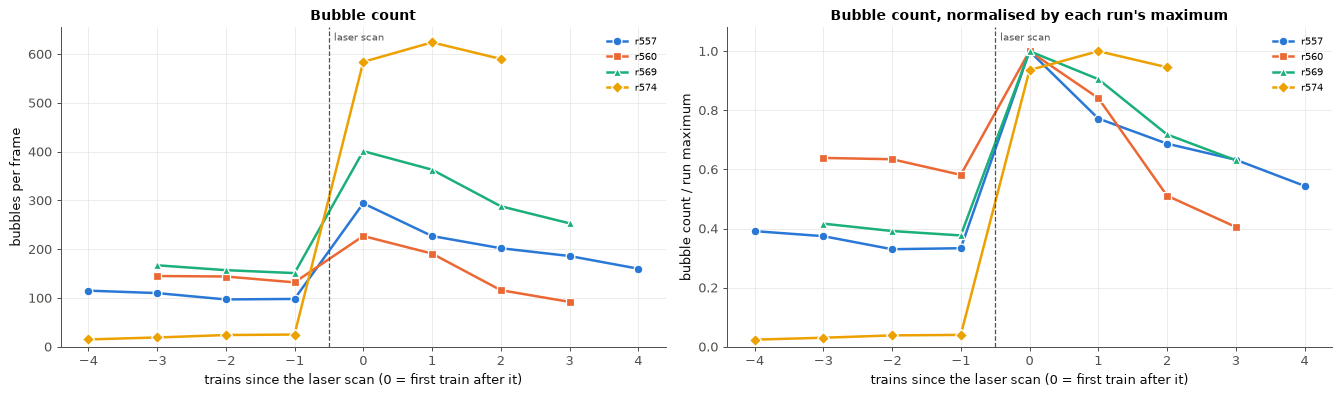

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
bst.plot_runs(A, "n_bubbles", "bubbles per frame", ax=ax[0], align=ALIGN_ON_SCAN, colors=COLORS, title="Bubble count")
bst.plot_runs(N, "n_bubbles", "bubble count", ax=ax[1], align=ALIGN_ON_SCAN, normalise=True, colors=COLORS,
              title="Bubble count, normalised by each run's maximum")
fig.tight_layout()
save(fig, "count_runs")

## 4. Bubble size

Mean and median describe the typical bubble, the Sauter radius r₃₂ the large ones (which hold most of the gas). A drop at the scan is the new population of small bubbles.

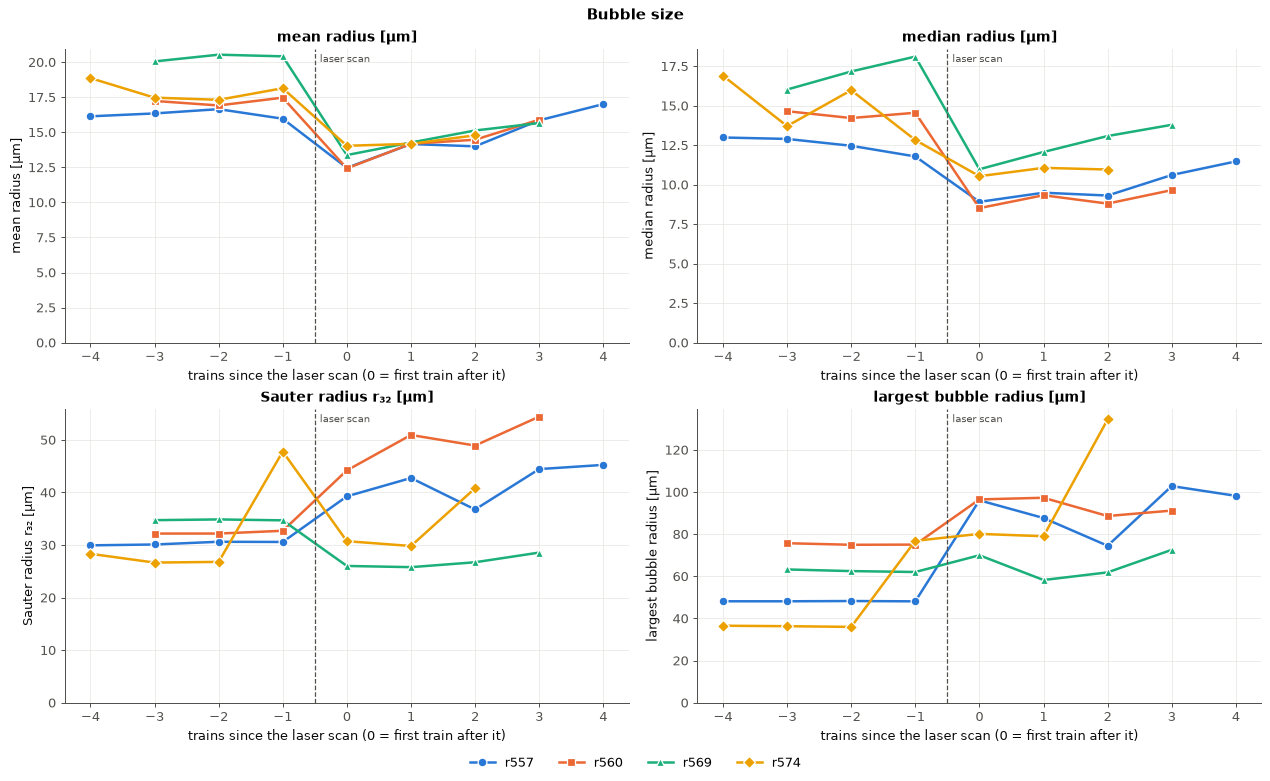

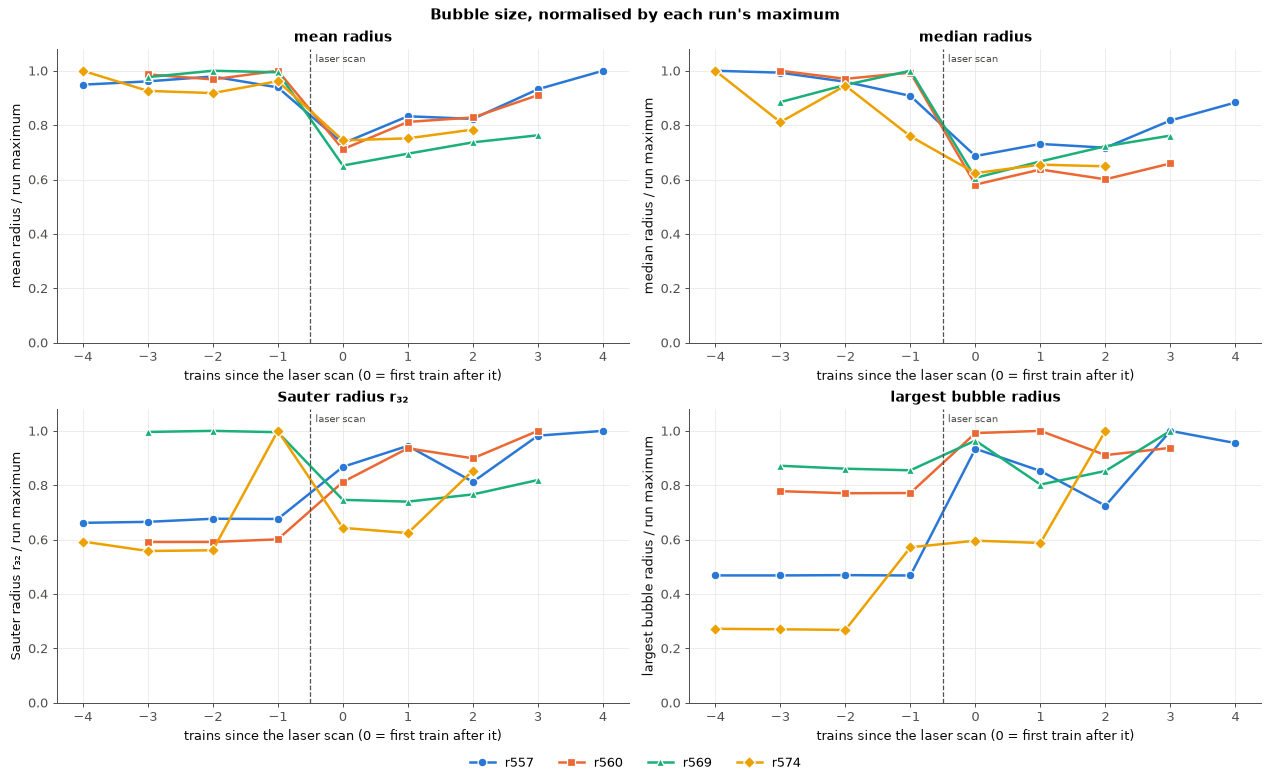

In [6]:
SIZE = [("r_mean_um", "mean radius [µm]"), ("r_median_um", "median radius [µm]"),
        ("r32_um", "Sauter radius r₃₂ [µm]"), ("r_max_um", "largest bubble radius [µm]")]
fig = bst.plot_runs_grid(A, SIZE, align=ALIGN_ON_SCAN, colors=COLORS, suptitle="Bubble size")
save(fig, "size_runs")
fig = bst.plot_runs_grid(N, SIZE, align=ALIGN_ON_SCAN, normalise=True, colors=COLORS,
                         suptitle="Bubble size, normalised by each run's maximum")
save(fig, "size_runs_normalised")

## 5. Total bubble area

**Total** adds up all bubble areas (overlaps counted fully), **covered** is the area under at least one bubble.

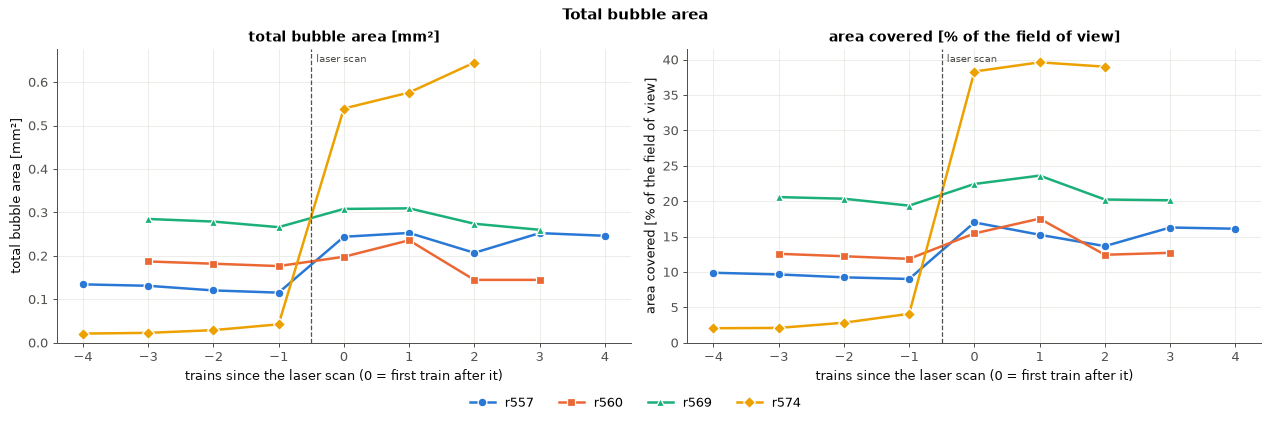

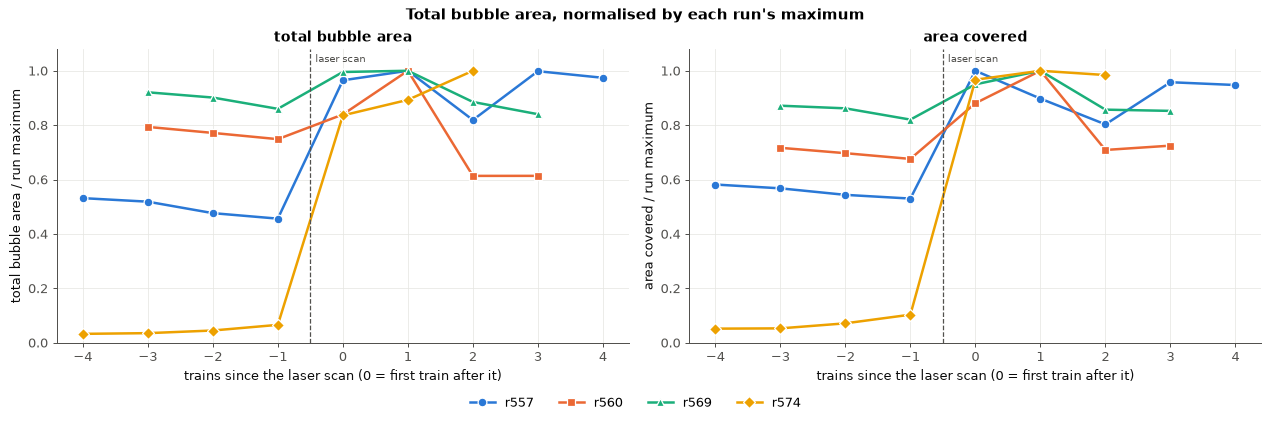

In [7]:
AREA = [("area_total_um2", "total bubble area [mm²]", 1e-6)] + \
       ([("coverage_frac", "area covered [% of the field of view]", 100)] if COMPUTE_COVERAGE else [])
fig = bst.plot_runs_grid(A, AREA, align=ALIGN_ON_SCAN, colors=COLORS, suptitle="Total bubble area")
save(fig, "area_runs")
fig = bst.plot_runs_grid(N, [p[:2] for p in AREA], align=ALIGN_ON_SCAN, normalise=True, colors=COLORS,
                         suptitle="Total bubble area, normalised by each run's maximum")
save(fig, "area_runs_normalised")

## 6. Polydispersity, shape and volume

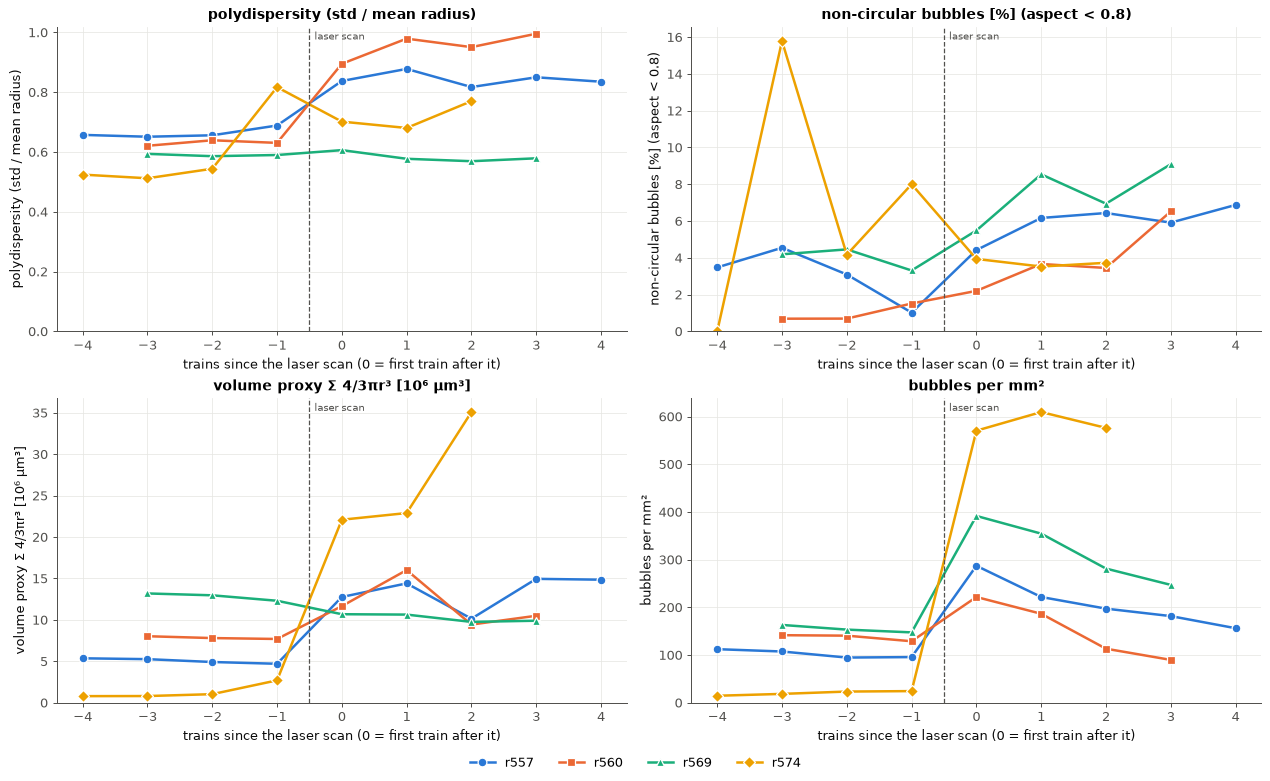

In [8]:
OTHER = [("polydispersity", "polydispersity (std / mean radius)"),
         ("frac_noncircular", "non-circular bubbles [%] (aspect < 0.8)", 100),
         ("volume_um3", "volume proxy Σ 4/3πr³ [10⁶ µm³]", 1e-6), ("density_per_mm2", "bubbles per mm²")]
fig = bst.plot_runs_grid(A, OTHER, align=ALIGN_ON_SCAN, colors=COLORS)
save(fig, "other_runs")

## 7. The jump at the scan

Last train before the scan vs the scan train, per run.

In [9]:
jump = bst.scan_jump_table(mt, scan)
display(jump.set_index("run").filter(like="ratio").round(2))
display(jump.set_index("run").round(3))

,n_bubbles ratio,r_mean_um ratio,r_median_um ratio,r32_um ratio,area_total_um2 ratio,coverage_frac ratio
run,,,,,,
r557,3.00,0.78,0.76,1.28,2.11,1.89
r560,1.72,0.71,0.59,1.35,1.12,1.30
r569,2.66,0.66,0.61,0.75,1.16,1.16
r574,23.36,0.77,0.82,0.64,12.71,9.37


,scan_train,n_bubbles before,n_bubbles after,n_bubbles ratio,r_mean_um before,r_mean_um after,r_mean_um ratio,r_median_um before,r_median_um after,r_median_um ratio,r32_um before,r32_um after,r32_um ratio,area_total_um2 before,area_total_um2 after,area_total_um2 ratio,coverage_frac before,coverage_frac after,coverage_frac ratio
run,,,,,,,,,,,,,,,,,,,
r557,4,98.0,294.0,3.000,15.967,12.466,0.781,11.789,8.914,0.756,30.585,39.258,1.284,115324.995,243891.937,2.115,0.090,0.170,1.886
r560,3,132.0,227.0,1.720,17.470,12.424,0.711,14.555,8.517,0.585,32.712,44.197,1.351,176494.263,197891.203,1.121,0.119,0.154,1.303
r569,3,151.0,401.0,2.656,20.416,13.375,0.655,18.112,10.978,0.606,34.700,26.023,0.750,266075.842,307995.445,1.158,0.194,0.224,1.158
r574,4,25.0,584.0,23.360,18.142,14.036,0.774,12.830,10.538,0.821,47.776,30.734,0.643,42409.935,539101.006,12.712,0.041,0.383,9.373


## 8. Size distribution before and after the scan

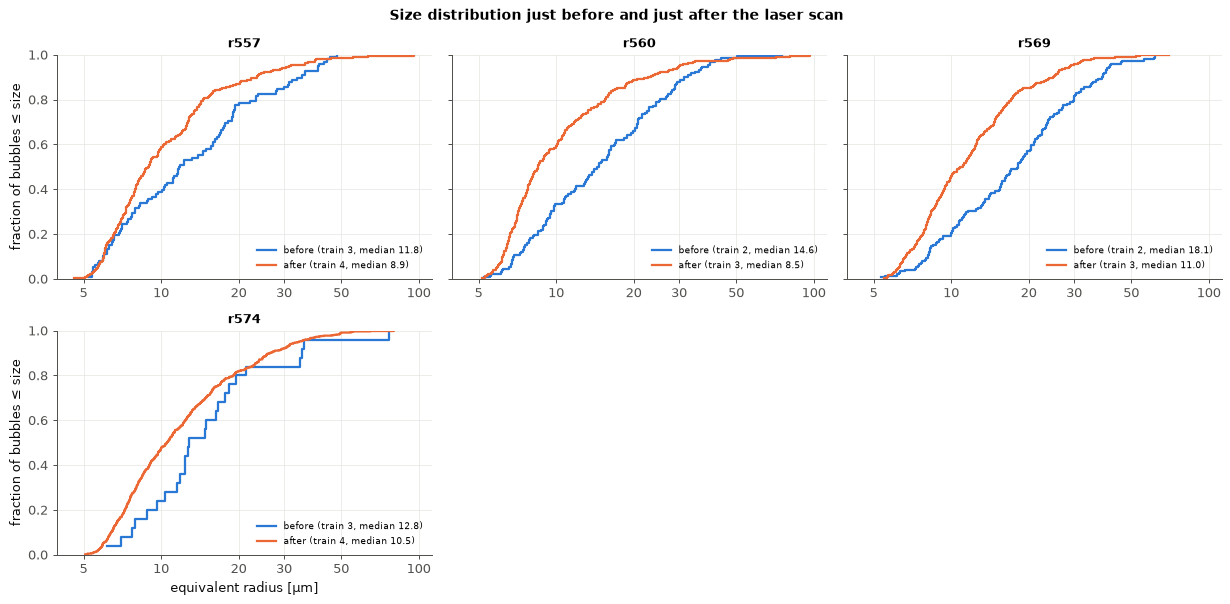

In [10]:
fig = bst.plot_size_before_after(bubbles, scan)
save(fig, "size_before_after")

## Notes

* Runs with no clear jump (largest rise below `MIN_JUMP`) are left out of the aligned figures; set their
  scan train in `SCAN_TRAINS`, or use `ALIGN_ON_SCAN = False` to plot every run against its train number.
* Normalised values divide each run by its own maximum (over all its trains), so the curves show the shape of each
  run's evolution, not its size: compare absolute values in the left / first figures.
* To compare more than 8 runs, split them into groups (one notebook run per group).